<a href="https://colab.research.google.com/github/Himanshu-86/ML_2026/blob/main/Practical_10_Multiple_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical 10: Multiple Linear Regression – Insurance Dataset

## Objective
To build a Multiple Linear Regression model to predict medical insurance charges based on features like age, BMI, smoking status, and number of children.

## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Load Dataset

In [ ]:
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92
1,18,male,33.770,1,no,southeast,1725.55
2,28,male,33.000,3,no,southeast,4449.46
3,33,male,22.705,0,no,northwest,21984.47
4,32,male,28.880,0,no,northwest,3866.85


## Data Exploration

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       20 non-null     int64  
 1   sex       20 non-null     object 
 2   bmi       20 non-null     float64
 3   children  20 non-null     int64  
 4   smoker    20 non-null     object 
 5   region    20 non-null     object 
 6   charges   20 non-null     float64
dtypes: float64(2), int64(2), object(3)
memory usage: 1.2+ KB


,age,bmi,children,charges
count,20.000000,20.000000,20.000000,20.000000
mean,35.700000,30.626500,0.600000,12452.424500
std,14.509888,5.710018,0.994723,12115.206301
min,18.000000,22.705000,0.000000,1725.550000
25%,24.500000,26.125000,0.000000,3497.795000
50%,31.500000,29.355000,0.000000,7761.045000
75%,47.500000,33.927500,1.000000,18159.807500
max,62.000000,42.130000,3.000000,39611.760000


## Visualization: Smoking vs Charges

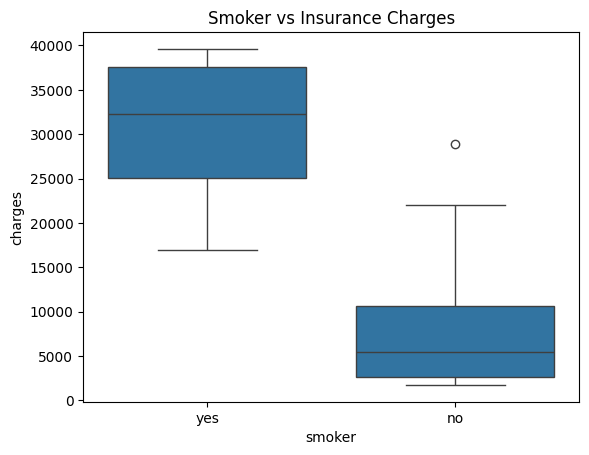

In [ ]:
sns.boxplot(x="smoker", y="charges", data=df)
plt.title("Smoker vs Insurance Charges")
plt.show()

## Data Preprocessing

In [ ]:
# Convert categorical variables to numeric
df = pd.get_dummies(df, columns=['sex','smoker','region'], drop_first=True)

X = df.drop("charges", axis=1)
y = df["charges"]

## Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Train Model

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

## Prediction

In [ ]:
y_pred = model.predict(X_test)

## Model Evaluation

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 4059.593258458874
MSE: 30053566.22016962
RMSE: 5482.113298735226
R2 Score: 0.2790361538750751


## Visualization: Actual vs Predicted

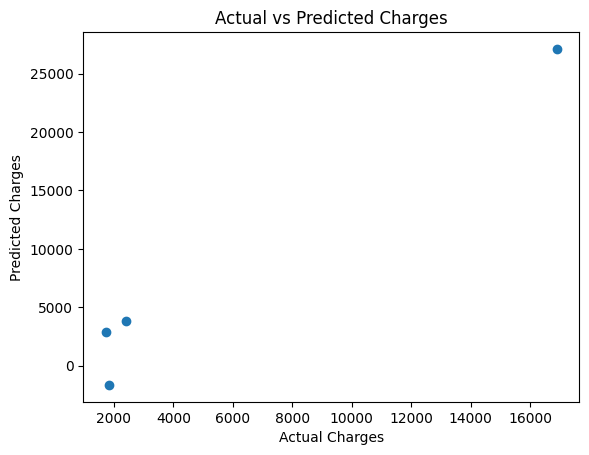

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")
plt.show()

## Conclusion

Multiple Linear Regression successfully predicted insurance charges. Smoking status and BMI showed strong influence on medical costs.